In [1]:
#1) IMPORT NECESSARY LIBRARIES

import pandas as pd
import pmdarima as pm
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#2) LOAD THE DATA
data=pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/nike/nike_data.csv')

In [3]:
#3) DO SOME CLEANING IF NECESSARY

data = data.drop(columns=['Unnamed: 0'])

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d", errors="coerce")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

In [4]:
#4) CREATE BACKTESTING DATASET

data_bt = data.iloc[:-4]

START THE SET UP FOR THE PROPHET MODEL

In [5]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº of quarters to forecast
FREQ = "Q"            # trimestral frecuency
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df[REG_COLS] = df[REG_COLS].ffill()

In [6]:
#5) ADD A FUTURE BASE SCENARIO SO PROPHET CAN FORECAST - BACKTESTING DATASET

# ================== PREP ====================
df_bt = data_bt.copy()

# Make sure that the regressors exist (if any are missing, we create them as Nan)  
for c in REG_COLS:
    if c not in df_bt.columns:
        df_bt[c] = np.nan

# Convert gdp_growth to numeric if it's not already
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Fill empty slots with forward-fill (opcional but usefull for training)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

SET UP THE ARIMA MODEL TO FORECAST THE REGRESSORS

In [7]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS
# ================== FUTURE SCENARIO ==================

revenue = data.set_index("ds")["revenue_musd"]
net_income = data.set_index("ds")["net_income_musd"]
total_assets = data.set_index("ds")["total_assets_musd"]
total_liabilities = data.set_index("ds")["total_liabilities_musd"]
total_equity = data.set_index("ds")["share_holder_equity_musd"]

metrics = {
    "revenue":revenue,
    "net_income": net_income,
    "total_assets": total_assets,
    "total_liabilities": total_liabilities,
    "total_equity": total_equity
    }

results = {}

for name, series in metrics.items():
    print(f"\nFitting model for {name}...")
    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results[name] = model
    print(f"Best order for {name}: {model.order}, seasonal: {model.seasonal_order}")

forecast_dic = {}

for name, model in results.items():
    fc = model.predict(n_periods=4)
    forecast_dic[name] = fc
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (0, 1, 1), seasonal: (0, 0, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (1, 0, 0, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 1), seasonal: (0, 0, 0, 4)

-revenue forecast for next 4 quarters:
2025-08-31    11960.530721
2025-11-30    12081.112627
2026-02-28    12201.694532
2026-05-31    12322.276438
Freq: QE-NOV, dtype: float64

-net_income forecast for next 4 quarters:
2025-08-31    1311.629452
2025-11-30    1524.137148
2026-02-28    1442.181012
2026-05-31    1178.347260
Freq: QE-NOV, dtype: float64

-total_assets forecast for next 4 quarters:
2025-08-31    36122.157811
2025-11-30    35665.315622
2026-02-28    35208.473432
2026-05-31    34751.631243
Freq: QE-NOV, dtype: float64

-total_liabilities forecast for next 4 quarters:
2025-08-31    23279.208820
2025-11-30    23278.755366
2026-02-28    23201.009854
2026-05-31    23234.576177
Freq: QE-NOV, dtype: float64

-total_equity forecast for next 4 quarters:
2025-08-31    12789.190651
2025-11-30    12365.381303
2026-02-28    11941.571954
2026-05-31    11517.762606
Freq: QE-NOV, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [8]:
# 6) CREATE ARIMA MODEL TO FORECAST REGRESSORS - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================

revenue_bt = data_bt.set_index("ds")["revenue_musd"]
net_income_bt = data_bt.set_index("ds")["net_income_musd"]
total_assets_bt = data_bt.set_index("ds")["total_assets_musd"]
total_liabilities_bt = data_bt.set_index("ds")["total_liabilities_musd"]
total_equity_bt = data_bt.set_index("ds")["share_holder_equity_musd"]

metrics_bt = {
    "revenue":revenue_bt,
    "net_income": net_income_bt,
    "total_assets": total_assets_bt,
    "total_liabilities": total_liabilities_bt,
    "total_equity": total_equity_bt
    }

results_bt = {}

for name, series in metrics_bt.items():
    print(f"\nFitting model for {name}...")
    model_bt = pm.auto_arima(
        series,
        seasonal=True, m=4,
        d=None, D=None,
        start_p=0, start_q=0, max_p=5, max_q=5,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        test="adf", seasonal_test="ocsb",
        suppress_warnings=True, error_action="ignore",
        allowdrift=True,
        trace=False,   # put True if you want detailed search output
    )
    results_bt[name] = model_bt
    print(f"Best order for {name}: {model_bt.order}, seasonal: {model_bt.seasonal_order}")

forecast_dic_bt = {}

for name, model in results_bt.items():
    fc_bt = model.predict(n_periods=4)
    forecast_dic_bt[name] = fc_bt
    print(f"\n-{name} forecast for next 4 quarters:")
    print(fc_bt)

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1


Fitting model for revenue...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for revenue: (3, 0, 0), seasonal: (0, 0, 0, 4)

Fitting model for net_income...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

...

/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_liabilities: (3, 2, 0), seasonal: (0, 0, 1, 4)

Fitting model for total_equity...


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

Best order for total_equity: (0, 2, 1), seasonal: (0, 0, 0, 4)

-revenue forecast for next 4 quarters:
2024-08-31    12750.538863
2024-11-30    12564.940101
2025-02-28    12531.159924
2025-05-31    12533.306308
Freq: QE-NOV, dtype: float64

-net_income forecast for next 4 quarters:
2024-08-31    1118.959701
2024-11-30    1095.292331
2025-02-28    1000.130198
2025-05-31     969.575760
Freq: QE-NOV, dtype: float64

-total_assets forecast for next 4 quarters:
2024-08-31    38329.966735
2024-11-30    38549.933470
2025-02-28    38769.900205
2025-05-31    38989.866940
Freq: QE-NOV, dtype: float64

-total_liabilities forecast for next 4 quarters:
2024-08-31    23408.980457
2024-11-30    23524.569194
2025-02-28    23693.106413
2025-05-31    23952.864216
Freq: QE-NOV, dtype: float64

-total_equity forecast for next 4 quarters:
2024-08-31    14555.032976
2024-11-30    14680.065952
2025-02-28    14805.098928
2025-05-31    14930.131905
Freq: QE-NOV, dtype: float64


/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1

In [9]:
#7) Create future dataframe for Prophet
# ================== FUTURE SCENARIO ==================
# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/659787550.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [10]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-05-31,11.503123,4713.0,342.0,13250.0,4557.0,8693.0,-3.23,0.15
1,2009-08-31,11.216619,4799.0,513.0,13191.0,4100.0,9091.0,-3.98,0.16
2,2009-11-30,13.202310,4405.0,375.0,13358.0,4134.0,9224.0,-3.13,0.12
3,2010-02-28,13.810738,4733.0,497.0,13576.0,4147.0,9429.0,0.11,0.11
4,2010-05-31,14.846562,5077.0,522.0,14419.0,4665.0,9754.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...
64,2025-05-31,59.878819,11097.0,211.0,36579.0,23366.0,13213.0,1.99,4.33
65,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
66,2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33
67,2026-03-31,NaN,NaN,NaN,NaN,NaN,NaN,1.99,4.33


In [11]:
#7) Create future dataframe for Prophet - BACKTESTING DATA
# ================== FUTURE SCENARIO ==================
# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/785312754.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [12]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA
forecast_dic = pd.DataFrame(forecast_dic)
forecast_dic = forecast_dic.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic = forecast_dic.reset_index()
forecast_dic = forecast_dic.rename(columns={"index": "ds"})
forecast_dic["ds"] = pd.to_datetime(forecast_dic["ds"])

In [13]:
forecast_dic

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2025-08-31,11960.530721,1311.629452,36122.157811,23279.208820,12789.190651
1,2025-11-30,12081.112627,1524.137148,35665.315622,23278.755366,12365.381303
2,2026-02-28,12201.694532,1442.181012,35208.473432,23201.009854,11941.571954
3,2026-05-31,12322.276438,1178.347260,34751.631243,23234.576177,11517.762606


In [14]:
#8) CREATE A DF WITH THE FORECASTED REGRESSORS WITH ARIMA - BACKTESTING DATA

forecast_dic_bt = pd.DataFrame(forecast_dic_bt)
forecast_dic_bt = forecast_dic_bt.rename(columns={
    "revenue": "revenue_musd",
    "net_income": "net_income_musd",
    "total_assets": "total_assets_musd",
    "total_liabilities": "total_liabilities_musd",
    "total_equity": "share_holder_equity_musd"
})

forecast_dic_bt = forecast_dic_bt.reset_index()
forecast_dic_bt = forecast_dic_bt.rename(columns={"index": "ds"})
forecast_dic_bt["ds"] = pd.to_datetime(forecast_dic_bt["ds"])

In [15]:
forecast_dic_bt

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd
0,2024-08-31,12750.538863,1118.959701,38329.966735,23408.980457,14555.032976
1,2024-11-30,12564.940101,1095.292331,38549.933470,23524.569194,14680.065952
2,2025-02-28,12531.159924,1000.130198,38769.900205,23693.106413,14805.098928
3,2025-05-31,12533.306308,969.575760,38989.866940,23952.864216,14930.131905


In [16]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET
future_full = pd.concat([future_full, forecast_dic], ignore_index=True)

future_full = future_full.sort_values(by="ds").reset_index(drop=True)
future_full = future_full.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full = future_full.drop_duplicates(subset=["ds"], keep="first")
future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/1001450928.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full[["gdp_growth", "interest_rate"]] = future_full[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-05-31,92.213409,12606.000000,1500.000000,38110.000000,23680.000000,14430.000000,2.90,5.33
61,2024-08-31,81.149361,11589.000000,1051.000000,37867.000000,23923.000000,13944.000000,3.04,5.33
62,2024-11-30,77.060097,12354.000000,1163.000000,37959.000000,23922.000000,14037.000000,2.72,4.83
63,2025-02-28,78.102379,11269.000000,794.000000,37793.000000,23786.000000,14007.000000,2.53,4.33
64,2025-05-31,59.878819,11097.000000,211.000000,36579.000000,23366.000000,13213.000000,1.99,4.33
65,2025-08-31,NaN,11960.530721,1311.629452,36122.157811,23279.208820,12789.190651,1.99,4.33
67,2025-11-30,NaN,12081.112627,1524.137148,35665.315622,23278.755366,12365.381303,1.99,4.33
69,2026-02-28,NaN,12201.694532,1442.181012,35208.473432,23201.009854,11941.571954,1.99,4.33
71,2026-05-31,NaN,12322.276438,1178.347260,34751.631243,23234.576177,11517.762606,1.99,4.33


In [17]:
#9) MERGE THE FORECASTED REGRESSORS WITH THE FUTURE DF FOR PROPHET - BACKTESTING DATA

future_full_bt = pd.concat([future_full_bt, forecast_dic_bt], ignore_index=True)

future_full_bt = future_full_bt.sort_values(by="ds").reset_index(drop=True)
future_full_bt = future_full_bt.dropna(subset=["revenue_musd", "net_income_musd", "total_assets_musd", "total_liabilities_musd", "share_holder_equity_musd"])
future_full_bt = future_full_bt.drop_duplicates(subset=["ds"], keep="first")
future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")
future_full_bt[60:]

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/79476634.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_full_bt[["gdp_growth", "interest_rate"]] = future_full_bt[["gdp_growth", "interest_rate"]].fillna(method="ffill")


,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
60,2024-05-31,92.213409,12606.000000,1500.000000,38110.000000,23680.000000,14430.000000,2.9,5.33
61,2024-08-31,NaN,12750.538863,1118.959701,38329.966735,23408.980457,14555.032976,2.9,5.33
63,2024-11-30,NaN,12564.940101,1095.292331,38549.933470,23524.569194,14680.065952,2.9,5.33
65,2025-02-28,NaN,12531.159924,1000.130198,38769.900205,23693.106413,14805.098928,2.9,5.33
67,2025-05-31,NaN,12533.306308,969.575760,38989.866940,23952.864216,14930.131905,2.9,5.33


In [18]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))


19:17:12 - cmdstanpy - INFO - Chain [1] start processing
19:17:12 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
57 2023-08-31   88.774574   79.455099   98.632623   97.665871
58 2023-11-30  102.687846   93.284424  112.676695  106.240669
59 2024-02-29   91.581550   82.241941  100.543829  100.469452
60 2024-05-31   91.055740   81.440150  100.992313   92.213409
61 2024-08-31   80.359860   71.502646   90.166477   81.149361
62 2024-11-30   90.805325   81.782806  100.178816   77.060097
63 2025-02-28   86.789531   77.833101   96.578481   78.102379
64 2025-05-31   71.609545   62.589832   81.409985   59.878819
65 2025-08-31   84.882274   75.338887   94.047632         NaN
66 2025-11-30   94.966518   84.790232  104.275633         NaN
67 2026-02-28   96.702151   88.255321  106.665675         NaN
68 2026-05-31   86.373717   76.949854   95.735785         NaN


In [19]:
#10) INITIALIZE, FIT AND PREDICT WITH PROPHET - BACKTESTING DATA

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

19:17:12 - cmdstanpy - INFO - Chain [1] start processing
19:17:12 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
53 2022-08-31  119.146124  111.149646  128.927494  100.991386
54 2022-11-30  117.655587  109.051842  126.032699  104.364174
55 2023-02-28  104.995183   96.392919  113.283841  113.369247
56 2023-05-31   95.239461   86.145148  104.024048  100.743118
57 2023-08-31   93.881389   84.700858  102.662133   97.665871
58 2023-11-30  104.781118   96.202820  113.983473  106.240669
59 2024-02-29   98.116275   89.082463  107.028533  100.469452
60 2024-05-31   97.036688   87.677878  106.040944   92.213409
61 2024-08-31   94.946867   85.453903  104.400070         NaN
62 2024-11-30   98.697789   89.580099  107.319049         NaN
63 2025-02-28   98.535608   89.687429  107.666562         NaN
64 2025-05-31   92.305198   83.740881  100.877139         NaN


In [20]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 5.669458418639954
RMSE: 56.55727722793192
R²: 0.9618266351118714
           ds        yhat  yhat_lower  yhat_upper           y  is_future
57 2023-08-31   88.774574   79.455099   98.632623   97.665871      False
58 2023-11-30  102.687846   93.284424  112.676695  106.240669      False
59 2024-02-29   91.581550   82.241941  100.543829  100.469452      False
60 2024-05-31   91.055740   81.440150  100.992313   92.213409      False
61 2024-08-31   80.359860   71.502646   90.166477   81.149361      False
62 2024-11-30   90.805325   81.782806  100.178816   77.060097      False
63 2025-02-28   86.789531   77.833101   96.578481   78.102379      False
64 2025-05-31   71.609545   62.589832   81.409985   59.878819      False
65 2025-08-31   84.882274   75.338887   94.047632         NaN       True
66 2025-11-30   94.966518   84.790232  104.275633         NaN       True
67 2026-02-28   96.702151   88.255321  106.665675         NaN       True
68 2026-05-31   86.373717   76.949854   95.735785     

In [21]:
#11) EVALUATE THE MODEL AND FLAG FUTURE ROWS - BACKTESTING DATA

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 5.057977763030002
RMSE: 48.11669040985653
R²: 0.9692339055289041
           ds        yhat  yhat_lower  yhat_upper           y  is_future
53 2022-08-31  119.146124  111.149646  128.927494  100.991386      False
54 2022-11-30  117.655587  109.051842  126.032699  104.364174      False
55 2023-02-28  104.995183   96.392919  113.283841  113.369247      False
56 2023-05-31   95.239461   86.145148  104.024048  100.743118      False
57 2023-08-31   93.881389   84.700858  102.662133   97.665871      False
58 2023-11-30  104.781118   96.202820  113.983473  106.240669      False
59 2024-02-29   98.116275   89.082463  107.028533  100.469452      False
60 2024-05-31   97.036688   87.677878  106.040944   92.213409      False
61 2024-08-31   94.946867   85.453903  104.400070         NaN       True
62 2024-11-30   98.697789   89.580099  107.319049         NaN       True
63 2025-02-28   98.535608   89.687429  107.666562         NaN       True
64 2025-05-31   92.305198   83.740881  100.877139     

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/433884081.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


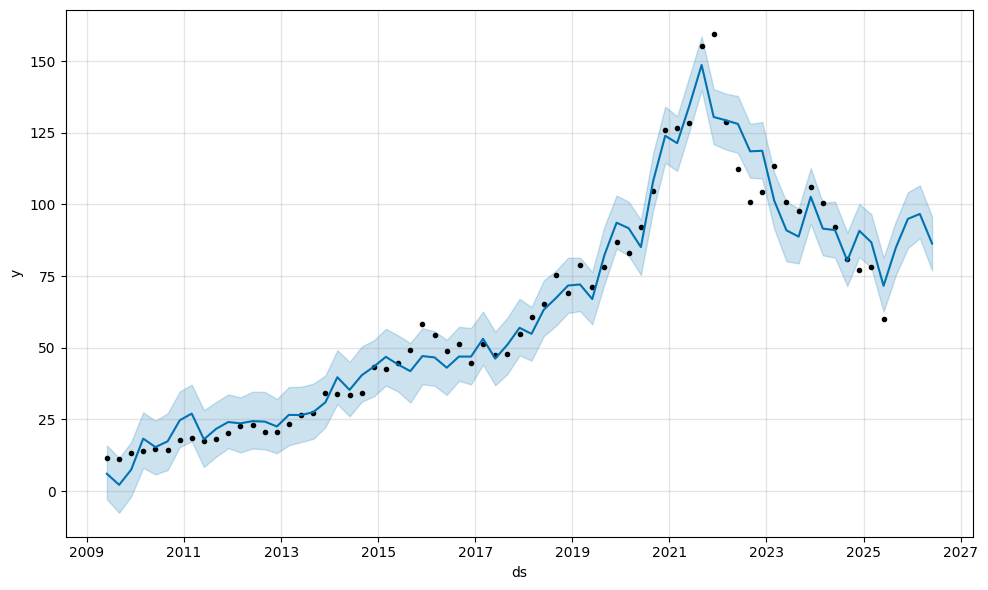

In [22]:
#12) PLOT THE RESULTS

figl = m.plot(forecast)
figl.show()

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_27897/3458915387.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


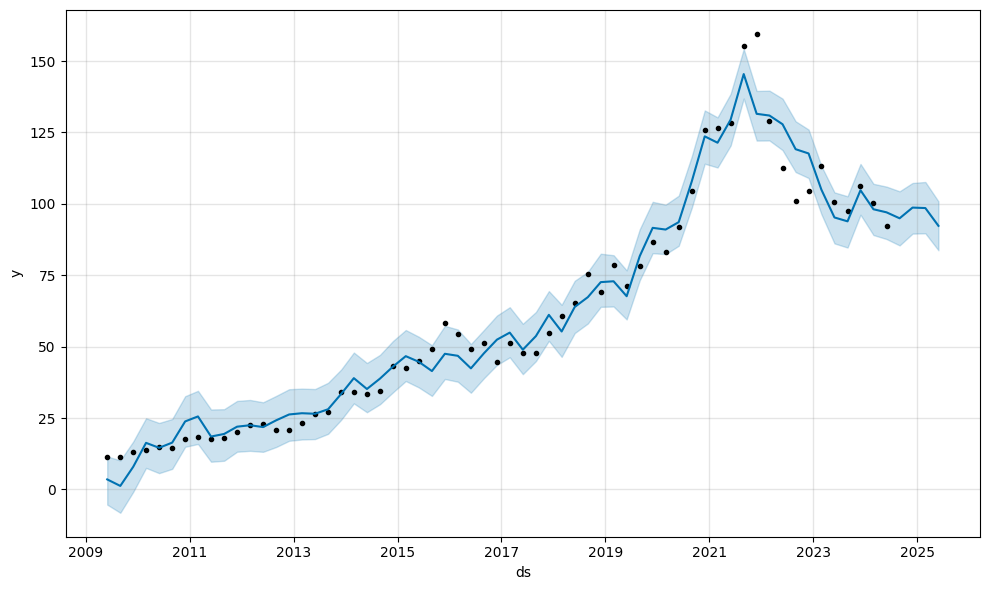

In [23]:
#12) PLOT THE RESULTS - BACKTESTING DATA

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()


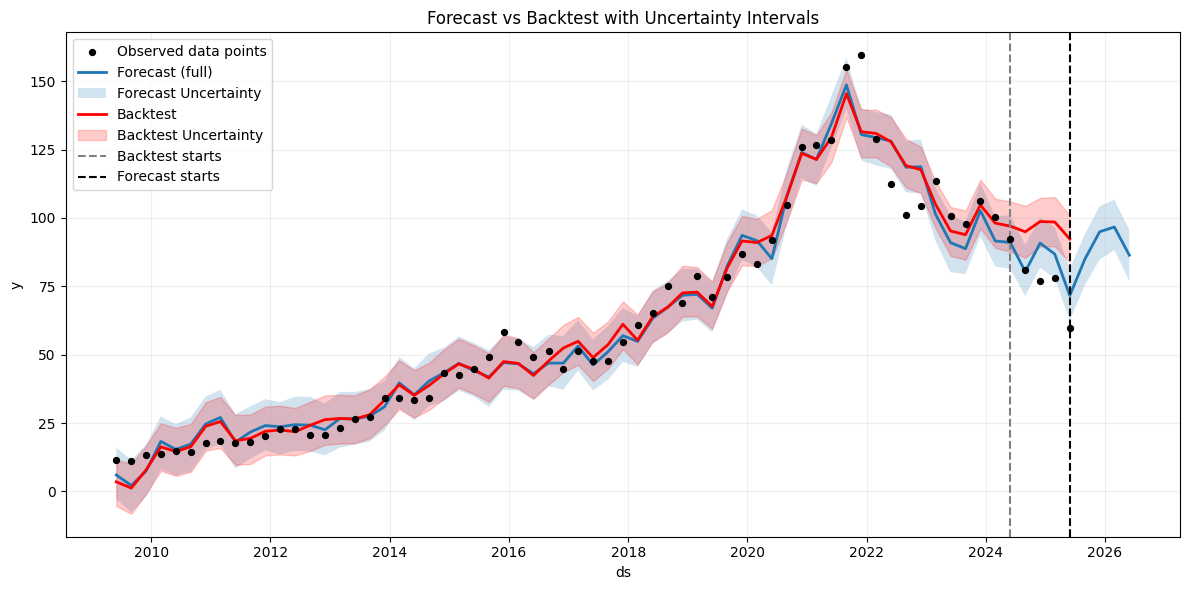

In [24]:
#13) PLOT THE FORECAST VS BACKTEST WITH UNCERTAINTY INTERVALS

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'].eq(False), 'ds'].max()   # ~2024-06-30
full_split = results.loc[results['is_future'].eq(False), 'ds'].max()         # ~2025-06-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()